In [1]:
def trial_by_trial(spike_times, event_times, pre, post, bin_size):
    post = post+1 #Literal voodoo. If this is taken out, all PSTHs will have an empty bin for some reason.
    spike_times = np.array(spike_times).astype(float)+pre
    event_times = np.array(event_times).astype(float)

    numbins  = np.ceil((pre+post)/bin_size).astype(int)
    bytrial  = np.zeros((len(event_times),numbins))
    var      = np.zeros((2,bytrial.shape[1]))
    psth     = np.zeros((2,bytrial.shape[1]))
    edges    = np.linspace(-pre+bin_size,post+bin_size,numbins)[2:-1]

    for t,time in enumerate(event_times):
        if len(np.where(spike_times >= time - pre)[0]) > 0 and len(np.where(spike_times >= time + post)[0]) > 0:
            start = np.where(spike_times >= time - pre)[0][0]
            end   = np.where(spike_times >= time + post)[0][0]
            
            for trial_spike in spike_times[start:end-1]:
                if float(trial_spike-time)/float(bin_size) < float(numbins):
                    bytrial[t][int((trial_spike-time)/bin_size-1)] +=1   
        else:
            pass
    
            
    var  = np.nanstd(bytrial,axis=0)/bin_size/np.sqrt(len(event_times))
    psth = np.nanmean(bytrial,axis=0)/bin_size

    #constrain your psth to original pre/post size
    psth  = psth[2:-1]    
    var   = var[2:-1] 
    psth  = psth[(edges > -pre) & (edges < post-1)]
    var   = var[(edges > -pre) & (edges < post-1)]
    trials = []
    for trial in bytrial:
        trial = trial[2:-1]
        trial = trial[(edges > -pre) & (edges < post-1)]
        trials.append(trial)
    edges = edges[(edges > -pre) & (edges < post-1)]
    
    return psth, var, edges, trials

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cebra.datasets
from cebra import CEBRA
import pandas as pd
import os
import glob

In [3]:
df = pd.read_json(r'C:\Users\Kim\Documents\Data\final\df7.json')
df = df[df.group=='good']
df_reaches = pd.read_json(r'C:\Users\Kim\Documents\Data\final\df_reaches7.json')

In [5]:
df_wobble = pd.read_csv(r'C:\Users\Kim\Documents\Data\final\wobbleFeatures_IndivReaches.csv')

In [4]:
df_reaches = df_reaches.drop(['level_0'],axis=1)

In [5]:
df_reaches

,reachInit,reachMax,reachEnd,stim,end_category,behaviors,mouse,cohort,rMax_t,timepoint,index
0,1635,1661,1727,0,manualAnnotation,success,49,cntrl,15.853233,2.0,NaN
1,4679,4723,4783,0,manualAnnotation,success,49,cntrl,36.268633,2.0,NaN
2,11456,11480,11603,0,manualAnnotation,retrieval_fail,49,cntrl,81.319900,2.0,NaN
3,12513,12533,12570,0,reachLost,success,49,cntrl,88.340700,2.0,NaN
4,19353,19377,19441,0,manualAnnotation,success,49,cntrl,133.971967,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2814,491929,491946,491951,0,noPellet,grasp_fail,271,None,3311.253189,NaN,NaN
2815,493852,493877,493891,0,noPellet,grasp_fail,271,None,3324.127737,NaN,NaN
2816,501390,501406,501416,0,noPellet,grasp_fail,271,None,3374.326010,NaN,NaN
2817,504977,504998,505048,0,noPellet,reach_fail,271,None,3398.275030,NaN,NaN


# run individual mouse

In [32]:
mid = 5454
df_mouse = df[df.mouse==mid]
df_r = df_reaches[df_reaches.mouse==mid]

create behavior label

In [77]:
discrete_ZCAlabels = np.array(df_wobble[df_wobble.ID=='5454'].ZCA_Y) #wobble

In [ ]:
def get_trials(df,dfr,bin_size,pre,post)

In [118]:
def fwhm2std(window_size):
    fwhm = window_size/2.3548
    return fwhm

In [225]:
trial_averages = []
trial_concat = []
smoothTrial_concat = []
pre=0.3
post=0.1
bin_size = 0.001

for spike_times in df_mouse.times:
    spike_times = np.array(spike_times)
    event_times = list(df_r.rMax_t)
    psth, var, edges, trials = trial_by_trial(spike_times, event_times, pre=pre, post=post, bin_size=bin_size)
    reachx,reachy,reachz = trial_by_trial(frames, rMax_indices, pre=pre, post=post)
    #extract reaches of specific length equivalent to extracted neural data

    trial = []
    smoothed = []
    for i in trials:
        # SMOOTH
        u = pd.Series(i)
        std = fwhm2std(window_size)
        smoothed_time_series = u.rolling(window=window_size, win_type="gaussian", center=True).mean(std=std)
        x = np.array(smoothed_time_series)
        x = x[~np.isnan(x)]
        smoothed.extend(x)
        trial.extend(i)
    trial_concat.append(trial)
    smoothTrial_concat.append(smoothed)
    trial_averages.append(psth)

In [ ]:
#extract reaches of specific length equivalent to extracted neural data
reachx,reachy,reachz = trial_by_trial(frames, rMax_indices, pre=pre, post=post)

behavior labels for wobble

In [137]:
behavior_labels = []
num_bins = np.shape(x)[0] # change to i if not smoothed, x if smoothed
for zca in discrete_ZCAlabels:
    per_reach = [zca] * num_bins
    behavior_labels.extend(per_reach)

behavior labels for success and failure type

In [210]:
success_label = []
for behavior in df_r.behaviors:
    if behavior=='success':
        success_label.append(0)
    else:
        success_label.append(1)
behavior_labels = []
num_bins = np.shape(x)[0] # change to i if not smoothed, x if smoothed
for label in success_label:
    per_reach = [label] * num_bins
    behavior_labels.extend(per_reach)

random shuffle behavior labels

In [93]:
success_label = []
for behavior in df_r.behaviors:
    if behavior=='success':
        success_label.append(0)
    else:
        success_label.append(1)
success_label_rand = shuffle(np.array(success_label))
behavior_labels = []
num_bins = np.shape(x)[0] # change to i if not smoothed, x if smoothed
for label in success_label_rand:
    per_reach = [label] * num_bins
    behavior_labels.extend(per_reach)

NameError: name 'df_r' is not defined

In [232]:
np.shape(x)

(374,)

In [233]:
np.shape(behavior_labels)

(24684,)

In [234]:
np.shape(smoothTrial_concat)

(90, 24684)

# time with zero crossings behavior labels

In [235]:
#initialize model
max_iterations = 500
cebra_behavior_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=0.0001,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

In [236]:
# time x features
neural = np.array(smoothTrial_concat).T

In [239]:
np.shape(neural)

(24684, 90)

In [237]:
cebra_behavior_model.fit(neural,
                       np.array(behavior_labels))
cebra_behavior = cebra_behavior_model.transform(neural)

pos: -0.8599 neg:  7.0863 total:  6.2264 temperature:  1.0000: 100%|█████████████████████| 500/500 [00:09<00:00, 51.97it/s]


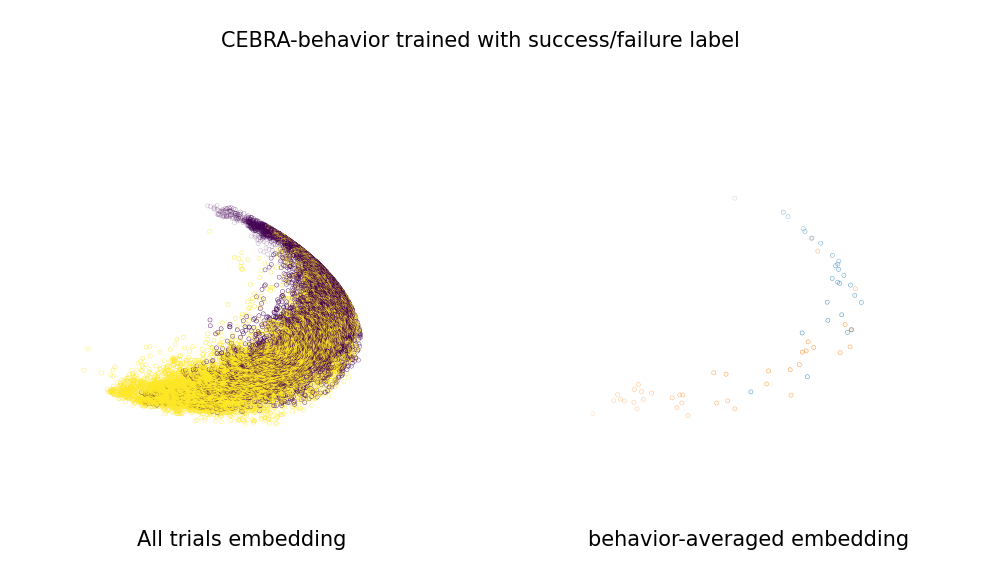

In [223]:
fig = plt.figure(figsize=(4, 2), dpi=300)
plt.suptitle('CEBRA-behavior trained with success/failure label',
             fontsize=5)
ax = plt.subplot(121, projection = '3d')
ax.set_title('All trials embedding', fontsize=5, y=-0.1)
x = ax.scatter(cebra_behavior[:, 0],
               cebra_behavior[:, 1],
               cebra_behavior[:, 2],
               c=behavior_labels,
               #cmap=plt.cm.hsv,
               s=0.01)
ax.axis('off')

ax = plt.subplot(122,projection = '3d')
ax.set_title('behavior-averaged embedding', fontsize=5, y=-0.1)
for i in range(2):
    behavior_trial = (np.array(behavior_labels) == i)
    trial_avg = cebra_behavior[behavior_trial, :].reshape(-1, 374,
                                                         3).mean(axis=1) # 374 is number of bins
    trial_avg_normed = trial_avg/np.linalg.norm(trial_avg, axis=1)[:,None]
    ax.scatter(trial_avg_normed[:, 0],
               trial_avg_normed[:, 1],
               trial_avg_normed[:, 2],
               #color=plt.cm.hsv(1 / 2 * i),
               s=0.01)
ax.axis('off')
plt.show()

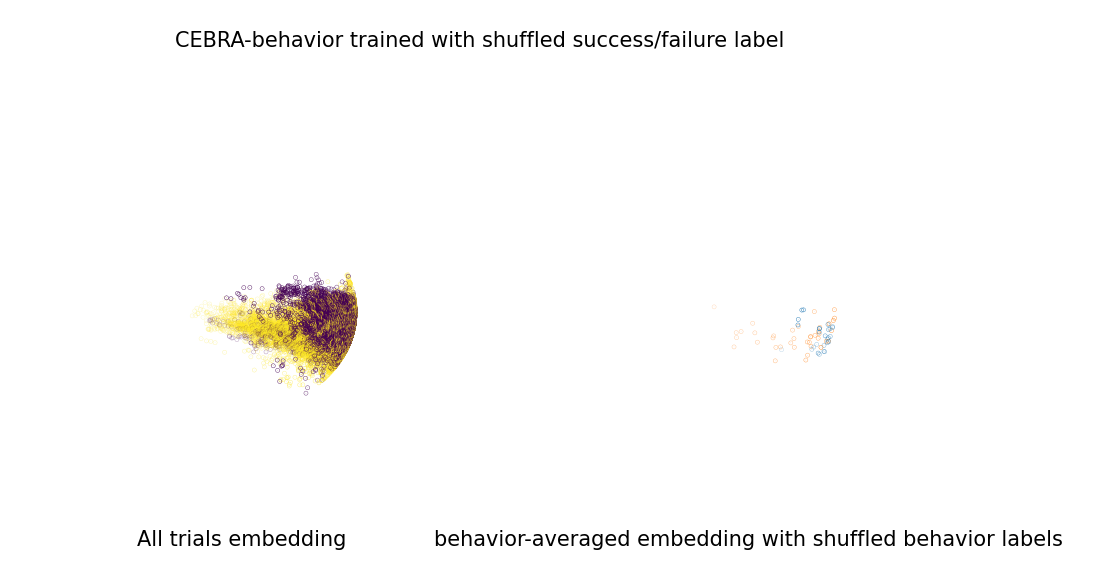

In [238]:
fig = plt.figure(figsize=(4, 2), dpi=300)
plt.suptitle('CEBRA-behavior trained with shuffled success/failure label',
             fontsize=5)
ax = plt.subplot(121, projection = '3d')
ax.set_title('All trials embedding', fontsize=5, y=-0.1)
x = ax.scatter(cebra_behavior[:, 0],
               cebra_behavior[:, 1],
               cebra_behavior[:, 2],
               c=behavior_labels,
               #cmap=plt.cm.hsv,
               s=0.01)
ax.axis('off')

ax = plt.subplot(122,projection = '3d')
ax.set_title('behavior-averaged embedding with shuffled behavior labels', fontsize=5, y=-0.1)
for i in range(2):
    behavior_trial = (np.array(behavior_labels) == i)
    trial_avg = cebra_behavior[behavior_trial, :].reshape(-1, 374,
                                                         3).mean(axis=1) # 374 is number of bins
    trial_avg_normed = trial_avg/np.linalg.norm(trial_avg, axis=1)[:,None]
    ax.scatter(trial_avg_normed[:, 0],
               trial_avg_normed[:, 1],
               trial_avg_normed[:, 2],
               #color=plt.cm.hsv(1 / 2 * i),
               s=0.01)
ax.axis('off')
plt.show()

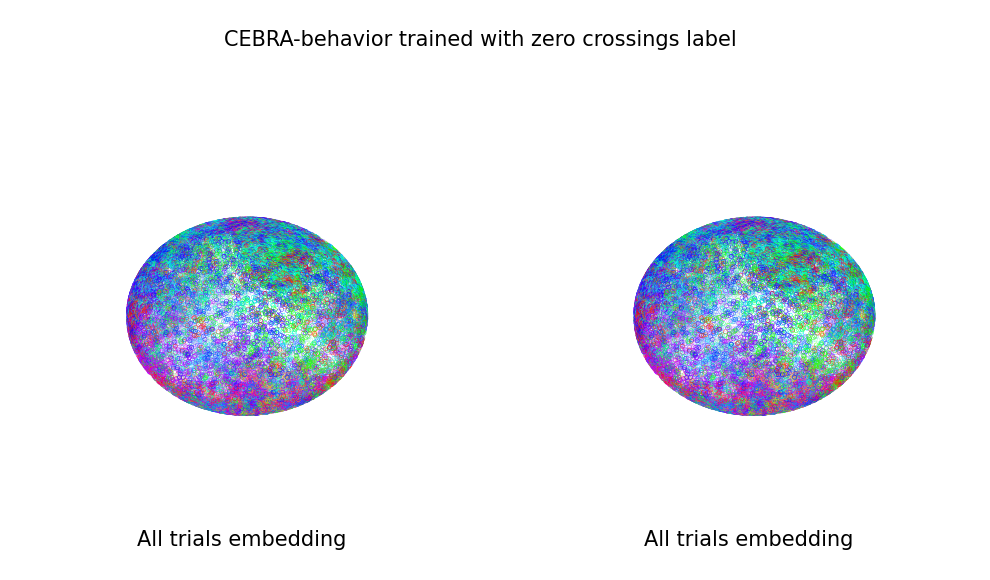

In [143]:
# with zca labels
fig = plt.figure(figsize=(4, 2), dpi=300)
plt.suptitle('CEBRA-behavior trained with zero crossings label',
             fontsize=5)
ax = plt.subplot(121, projection = '3d')
ax.set_title('All trials embedding', fontsize=5, y=-0.1)
x = ax.scatter(cebra_zca[:, 0],
               cebra_zca[:, 1],
               cebra_zca[:, 2],
               c=behavior_labels,
               cmap=plt.cm.hsv,
               s=0.01)
ax.axis('off')

ax = plt.subplot(122,projection = '3d')
ax.set_title('All trials embedding', fontsize=5, y=-0.1)
x = ax.scatter(cebra_zca[:, 0],
               cebra_zca[:, 1],
               cebra_zca[:, 2],
               c=behavior_labels,
               cmap=plt.cm.hsv,
               s=0.01)
ax.axis('off')
plt.show()


# time only (no behavior embedding)

In [ ]:
cebra_time3_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1.12,
                        output_dimension=3,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

In [115]:
time3_embeddings = cebra_time3_model.transform(neural)

In [63]:
#%matplotlib inline

In [116]:
embed = time3_embeddings.T

In [117]:
np.shape(time3_embeddings)

(5546, 3)

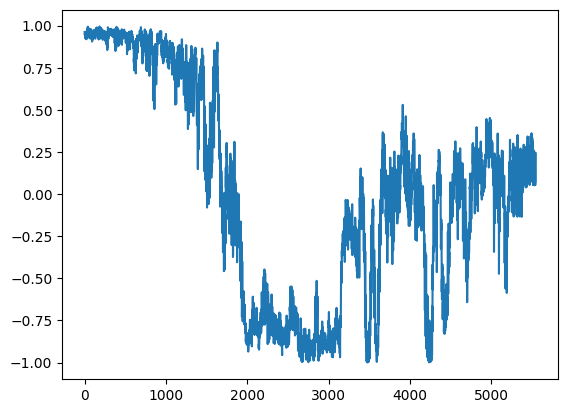

In [118]:
plt.plot(embed[1])

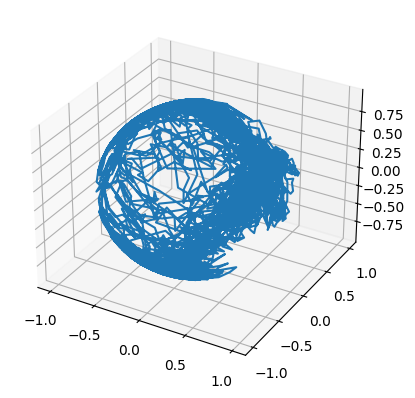

In [119]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(embed[0],embed[1],embed[2])
plt.show()
plt.close()

# fit to multiple mice

In [7]:
trial_averages = []
mouse_run = {}
pre=0.5
post=0.5
bin_size = 0.020
for mid in df.mouse.unique():
    df_mouse = df[df.mouse==mid]
    df_r = df_reaches[df_reaches.mouse==mid]
    trial_concat = []
    for spike_times in df_mouse.times:
        spike_times = np.array(spike_times)
        event_times = list(df_r.rMax_t)
        psth, var, edges, trials = trial_by_trial(spike_times, event_times, pre=pre, post=post, bin_size=bin_size)
        trial = []
        for i in trials:
            trial.extend(i)
        trial_concat.append(trial)
        trial_averages.append(psth)
    mouse_run[mid] = np.array(trial_concat).T

In [8]:
max_iterations = 15000 #default is 5000.

In [38]:
# create model (fit cebra)
for mouse in list(mouse_run.keys()):

    cebra_time3_model = CEBRA(model_architecture='offset10-model',
                            batch_size=512,
                            learning_rate=3e-4,
                            temperature=1.12,
                            output_dimension=3,
                            max_iterations=max_iterations,
                            distance='cosine',
                            conditional='time',
                            device='cuda_if_available',
                            verbose=True,
                            time_offsets=10)

    cebra_time3_model.fit(mouse_run[mouse])
    path = r'C:\Users\Kim\Documents\Data\cebra'
    #cebra_time3_model.save(f"cebra_time3_model_{mouse}.pt")
    cebra_time3_model.save(os.path.join(path,f"cebra_time3_model_{mouse}.pt"))

pos: -0.8913 neg:  6.3668 total:  5.4755 temperature:  1.1200: 100%|█████████████| 15000/15000 [02:54<00:00, 86.06it/s]
  0%|                                                                                        | 0/15000 [00:00<?, ?it/s]C:\Users\Kim\Anaconda3\envs\cebra\lib\site-packages\torch\nn\modules\conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,
C:\Users\Kim\Anaconda3\envs\cebra\lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variabl

In [9]:
time3_models, time3_embeddings = {}, {}
posdir3_models, posdir3_embeddings = {}, {}
left, right = {}, {}
path = r'C:\Users\Kim\Documents\Data\cebra'
for mouse in list(mouse_run.keys()):
    # time constrative models
    time3_models[mouse] = cebra.CEBRA.load(os.path.join(path,f"cebra_time3_model_{mouse}.pt"))
    time3_embeddings[mouse] = time3_models[mouse].transform(mouse_run[mouse])

   # left and right labels for the embedding
#    right[mouse] = mouse_run[mouse].continuous_index[:,1] == 1
#    left[mouse] = mouse_run[mouse].continuous_index[:,2] == 1

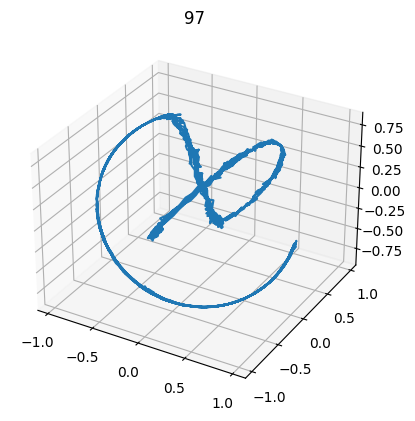

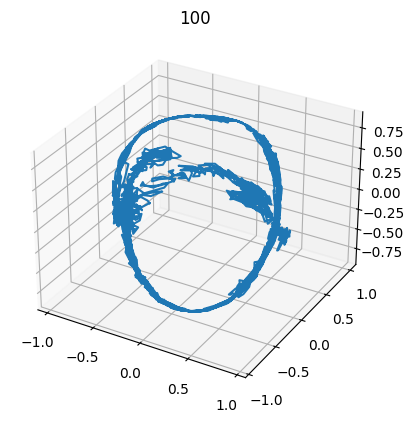

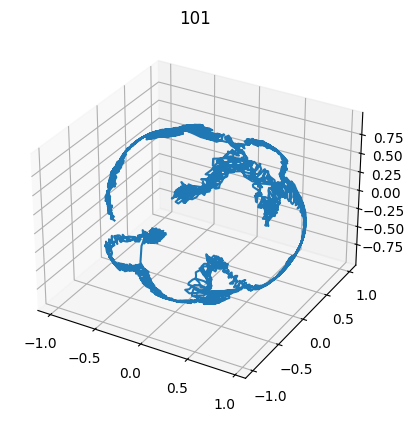

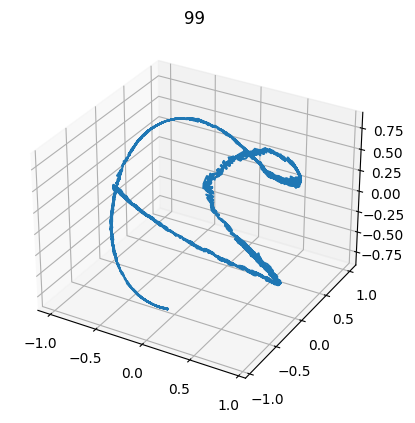

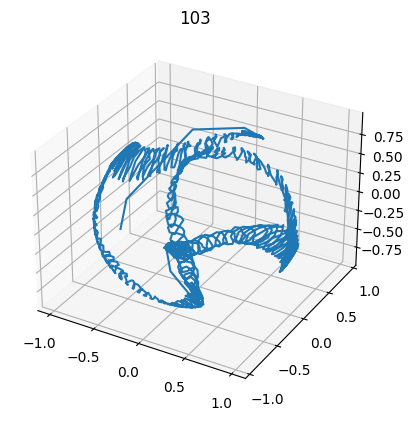

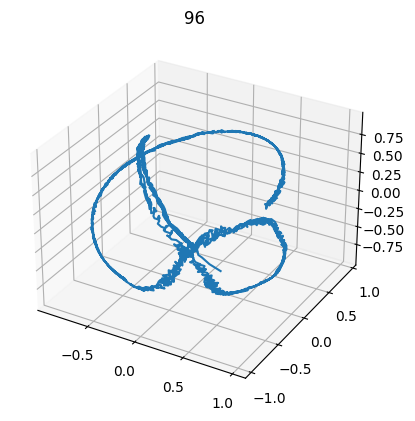

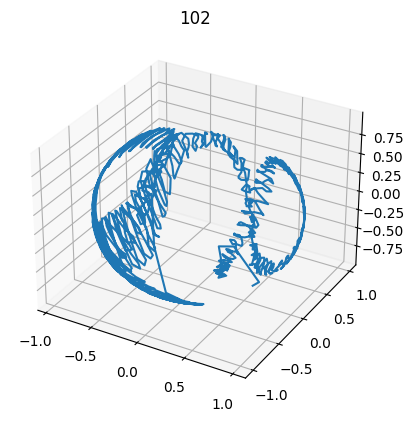

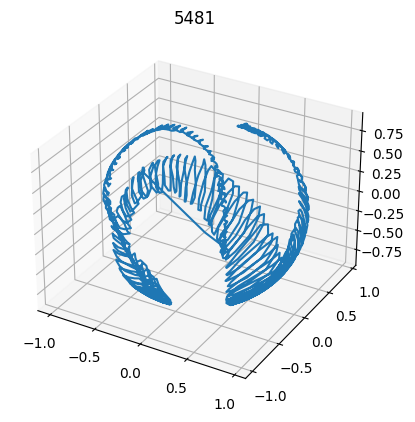

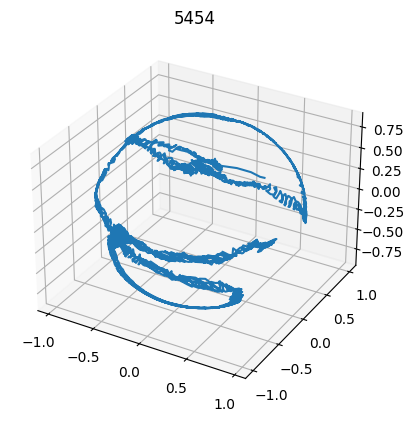

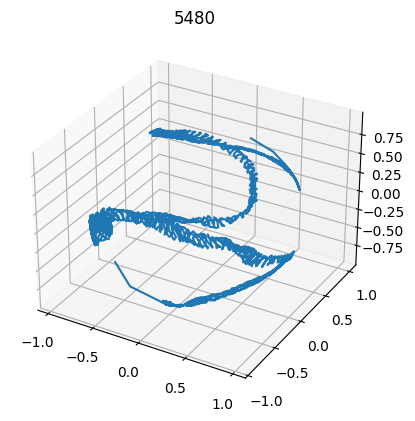

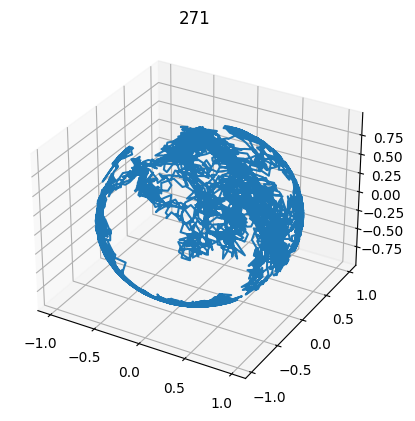

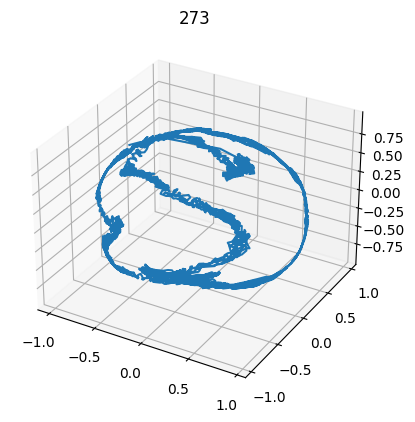

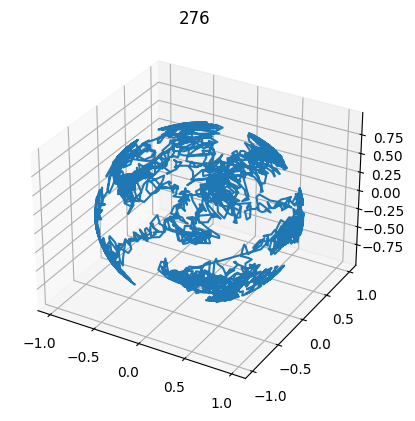

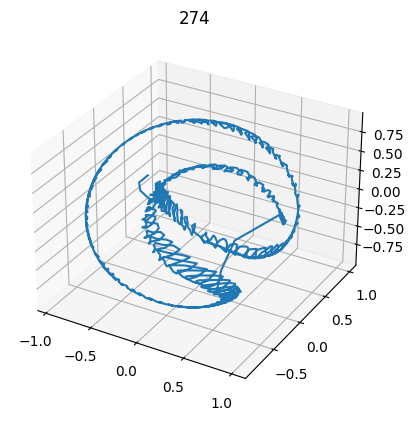

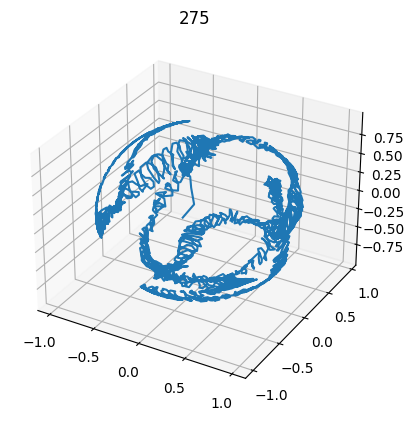

In [11]:
for mouse in time3_embeddings.keys():
    traj = time3_embeddings[mouse].T
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.plot3D(traj[0],traj[1],traj[2])
    plt.title(mouse)
    plt.show()
    plt.close()

In [ ]:
labels = [hippocampus_pos[mouse].continuous_index[:, 0]
          for mouse in list(hippocampus_pos.keys())]

# CEBRA-Time consistencies
time_scores, time_pairs, time_subjects = cebra.sklearn.metrics.consistency_score(embeddings=list(time3_embeddings.values()),
                                                                                 labels=labels,
                                                                                 dataset_ids=list(
                                                                                     time3_embeddings.keys()),
                                                                                 between="datasets")

# import kinematics

In [7]:
from os.path import dirname, join as pjoin
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import mat73
import glob


In [8]:
def createMatDict(mat_contents):
    mat_variables = {}

    # Iterate through each key in the mat_contents
    for key in mat_contents:
        # Skip the standard MATLAB fields
        if key not in ['__header__', '__version__', '__globals__', '__function_workspace__']:
            # Directly store the data
            mat_variables[key] = mat_contents[key]
    return mat_variables

In [10]:
def remove_dblReaches(dfr,mid,print_outputs=True):
    dfr = dfr[dfr.mouse==mid]
    if print_outputs==True:
        print(mid)
    dfr = dfr.sort_values(by=['rMax_t'])
    where_ind = np.where(np.diff(dfr.rMax_t)<1)
    if print_outputs==True:
        print(where_ind)
    #dfr = dfr.drop(['level_0'],axis=1)
    dfr = dfr.reset_index()
    dfr_removed = dfr.drop(index=where_ind[0]+1)
    return dfr_removed

In [64]:
df_reaches = df_reaches.drop(['level_0'],axis=1)

In [65]:
dfrs = [remove_dblReaches(df_reaches,mid,print_outputs=False) for mid in df_reaches.mouse.unique()]
df_reaches = pd.concat(dfrs,ignore_index=True)

In [69]:
for mid in df_reaches.mouse.unique():
    print(mid,np.shape(df_reaches[df_reaches.mouse==mid])[0])

49 89
53 104
56 56
58 57
59 84
65 77
66 47
67 37
68 67
69 66
71 77
100 101
101 78
102 24
103 30
104 67
156 40
159 43
161 60
164 15
166 50
167 24
168 62
170 64
203 57
208 38
209 131
5454 66
5473 39
5475 60
5477 39
5478 35
5480 52
5481 30
96 60
97 118
99 84
599 35
600 88
566 26
544 73
273 85
275 67
276 73
274 27
271 117


In [9]:
data_path = r'C:\Users\Kim\Documents\Data\final\kinematics_thresholded_extracted'
mids = []
#reachx = []
#reachy = []
xs_toMax = []
ys_toMax = []
max_ind = []
xs_toEnd = []
ys_toEnd = []
for folder in glob.glob(data_path+'/*'):
    mouse = os.path.basename(folder).split('_')[-3]
    mat_contents = mat73.loadmat(folder)
    mat_variables = createMatDict(mat_contents)
    #xs = []
    #ys = []
    for i,sess in enumerate(mat_variables['Sessions']['InitialToMax']):
        x = []
        y = []
        for xyz in sess['HandPositionNormalized']:
            x.append(xyz[0])
            y.append(xyz[1])
        xs_toMax.append(x)
        ys_toMax.append(y)
        max_ind.append(np.shape(x)[0])
        mids.append(mouse)

    for j,sess in enumerate(mat_variables['Sessions']['InitialToEnd']):
        x = []
        y = []
        for xyz in sess['HandPositionNormalized']:
            x.append(xyz[0])
            y.append(xyz[1])
        xs_toEnd.append(x)
        ys_toEnd.append(y)

ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB

In [10]:
df_kinematics = pd.DataFrame(data=mids,columns=['mouse'])
df_kinematics['xpos_toMax'] = xs_toMax
df_kinematics['ypos_toMax'] = ys_toMax
df_kinematics['max_ind'] = max_ind
df_kinematics['xpos_toEnd'] = xs_toEnd
df_kinematics['ypos_toEnd'] = ys_toEnd

In [11]:
init_toMax = []
max_toEnd = []
for i,m_ind in enumerate(df_kinematics.max_ind):
    begin = df_kinematics.xpos_toEnd[i][:m_ind]
    end = df_kinematics.xpos_toEnd[i][m_ind:]
    init_toMax.append(np.shape(begin)[0])
    max_toEnd.append(np.shape(end)[0])

In [12]:
df_kinematics['toMax'] = init_toMax
df_kinematics['toEnd'] = max_toEnd

In [13]:
df_kinematics

,mouse,xpos_toMax,ypos_toMax,max_ind,xpos_toEnd,ypos_toEnd,toMax,toEnd
0,097,"[-11.811527777777776, -10.178194444444443, -8....","[1.7695833333333333, 1.3762500000000006, 0.995...",7,"[-11.811527777777776, -10.178194444444443, -8....","[1.7695833333333333, 1.3762500000000006, 0.995...",7,11
1,097,"[-11.717083333333333, -9.38375, -7.18263888888...","[1.1362500000000004, 0.41069444444444514, -0.4...",6,"[-11.717083333333333, -9.38375, -7.18263888888...","[1.1362500000000004, 0.41069444444444514, -0.4...",6,28
2,097,"[-12.728194444444444, -11.821527777777778, -10...","[2.018472222222222, 0.8051388888888891, 1.2495...",9,"[-12.728194444444444, -11.821527777777778, -10...","[2.018472222222222, 0.8051388888888891, 1.2495...",9,22
3,097,"[-12.420416666666666, -11.732638888888888, -11...","[3.695138888888888, 2.9440277777777766, 2.2962...",24,"[-12.420416666666666, -11.732638888888888, -11...","[3.695138888888888, 2.9440277777777766, 2.2962...",24,32
4,097,"[-12.143749999999999, -10.205972222222222, -8....","[0.4551388888888894, 0.6395833333333325, -0.73...",9,"[-12.143749999999999, -10.205972222222222, -8....","[0.4551388888888894, 0.6395833333333325, -0.73...",9,43
...,...,...,...,...,...,...,...,...
1410,GN276,"[-12.925555555555556, -12.796666666666667, -12...","[6.520555555555555, 6.407222222222222, 6.33944...",19,"[-12.925555555555556, -12.796666666666667, -12...","[6.520555555555555, 6.407222222222222, 6.33944...",19,16
1411,GN276,"[-11.774444444444445, -11.242222222222223, -10...","[4.940555555555557, 4.656111111111111, 4.04722...",13,"[-11.774444444444445, -11.242222222222223, -10...","[4.940555555555557, 4.656111111111111, 4.04722...",13,25
1412,GN276,"[-12.602222222222222, -12.08, -11.993333333333...","[5.9350000000000005, 5.17277777777778, 4.85944...",14,"[-12.602222222222222, -12.08, -11.993333333333...","[5.9350000000000005, 5.17277777777778, 4.85944...",14,23
1413,GN276,"[-12.783333333333335, -12.413333333333334, -12...","[5.071666666666667, 4.489444444444446, 4.06388...",12,"[-12.783333333333335, -12.413333333333334, -12...","[5.071666666666667, 4.489444444444446, 4.06388...",12,11


In [14]:
df_kinematics.to_json(r'C:\Users\Kim\Documents\Data\kimdata\cebra\df_kinematics_df_kinematics_wDcntrls')

(0.0, 40.0)

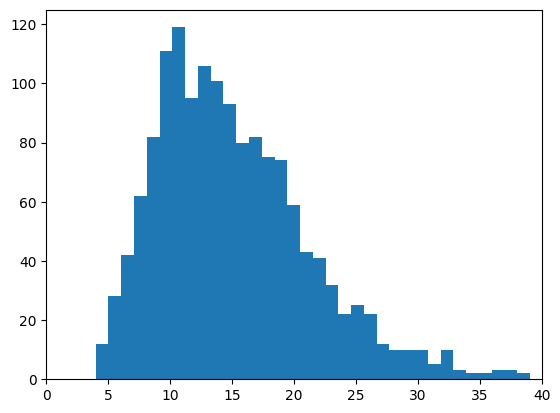

In [74]:
plt.hist(init_toMax,bins=100)
plt.xlim(0,40)

(0.0, 100.0)

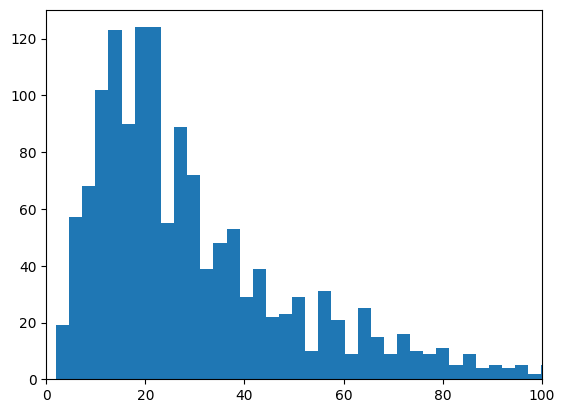

In [82]:
plt.hist(max_toEnd, bins=500)
plt.xlim(0,100)

In [90]:
np.shape(df_kinematics[df_kinematics.toMax<10])[0]/np.shape(df_kinematics)[0]

0.1522911051212938

In [92]:
np.shape(df_kinematics[df_kinematics.toEnd<10])[0]/np.shape(df_kinematics)[0]

0.09703504043126684

In [91]:
np.shape(df_kinematics[df_kinematics.toEnd<10])

(144, 8)

# run individual mouse with properly aligned kinematics

10 frames around reach max, pad and interpolate then truncate to number of neural data bins

# 5454 has same # of df_reaches and kinematic pipeline reaches

In [89]:
from scipy import signal

In [86]:
mid = 97
df_mouse = df[df.mouse==mid]
df_r = df_reaches[df_reaches.mouse==mid]

(59, 100)

In [111]:
trial_averages = []
trial_concat = []
pre=0.300
post=0.200
bin_size = 0.020
for spike_times in df_mouse.times:
    spike_times = np.array(spike_times)
    event_times = list(df_r.rMax_t)
    psth, var, edges, trials = trial_by_trial(spike_times, event_times, pre=pre, post=post, bin_size=bin_size)
    trial = []
    for i in trials:
        trial.extend(i) # ADD GAUSSIAN SMOOTHING HERE
    trial_concat.append(trial)
    trial_averages.append(psth)

In [112]:
np.shape(trial_concat)

(114, 1474)

resample kinematics to match neural data

In [103]:
xs = np.array(df_kinematics[df_kinematics.mouse=='5454'].xpos)[0]
ys = np.array(df_kinematics[df_kinematics.mouse=='5454'].ypos)[0]

In [110]:
100*66

6600

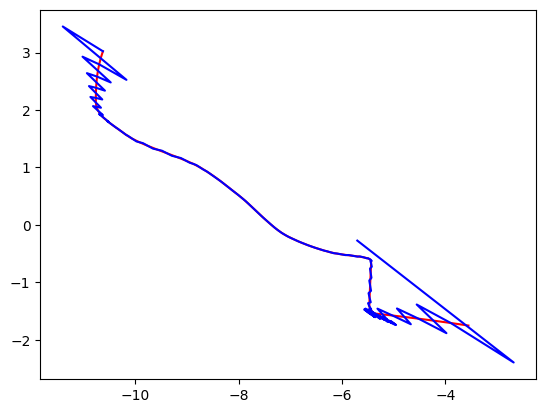

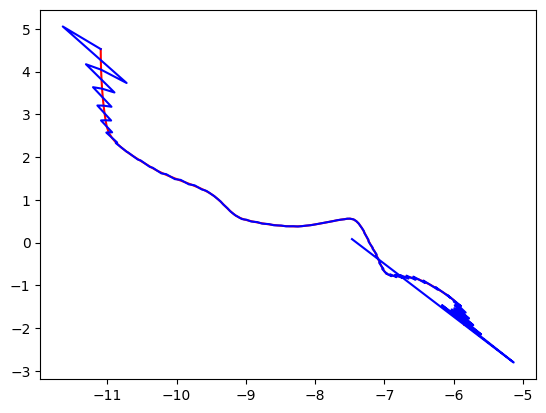

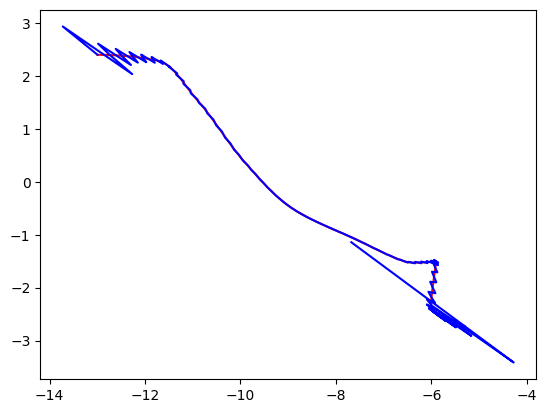

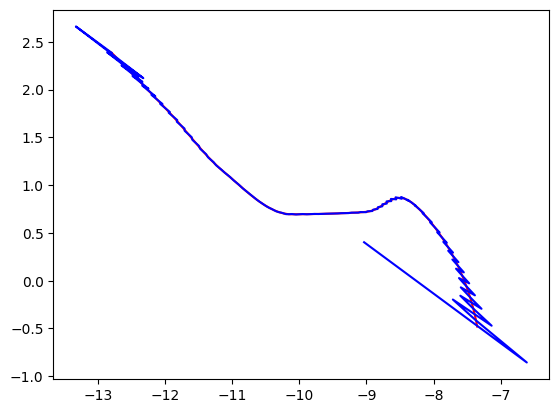

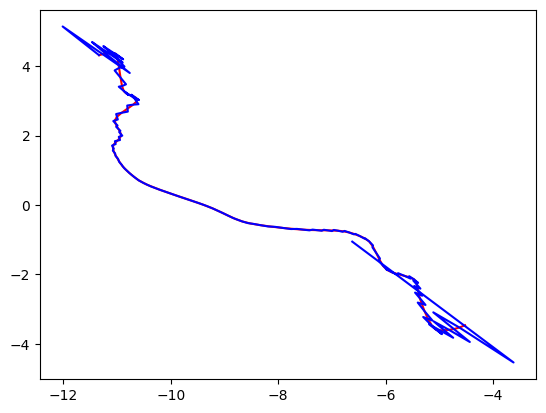

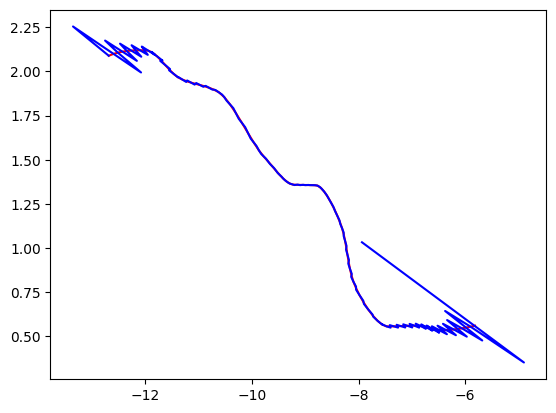

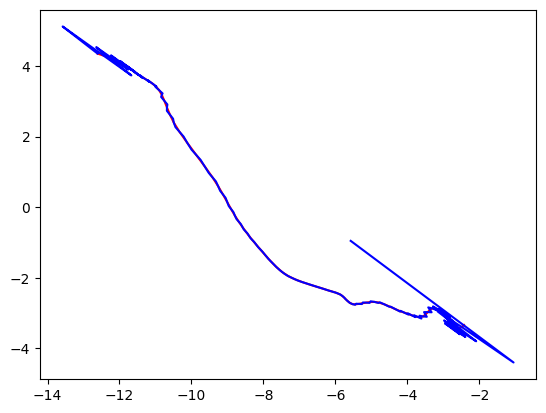

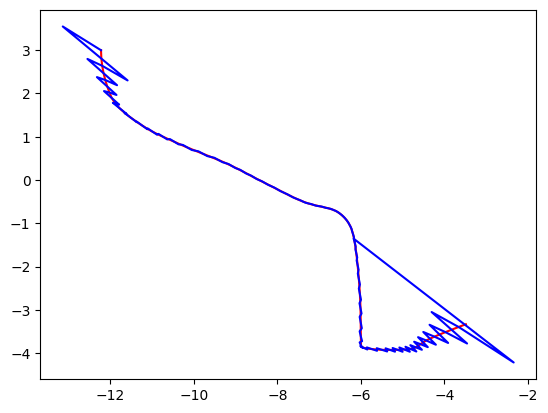

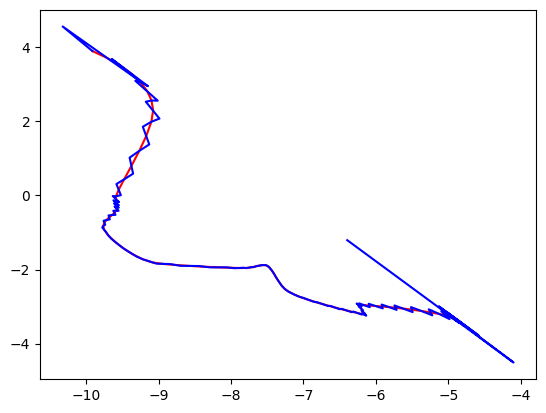

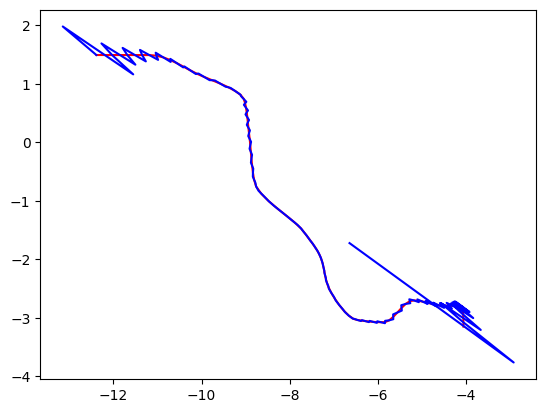

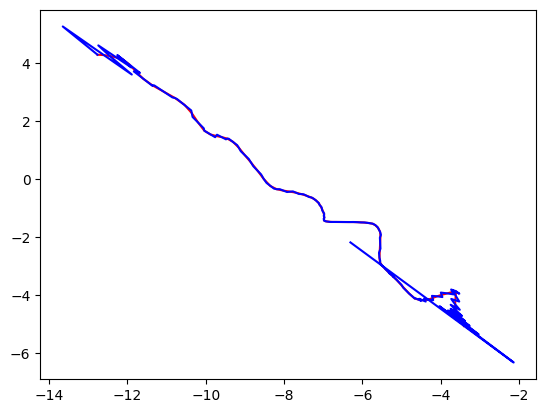

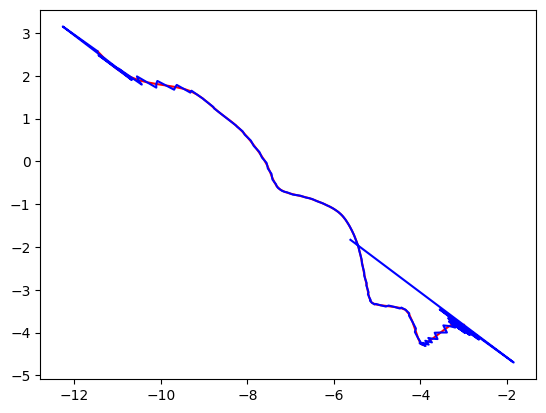

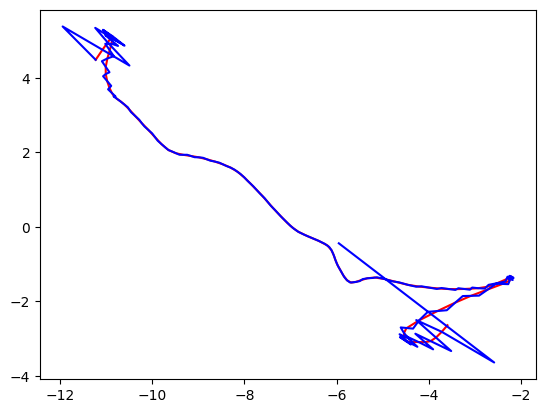

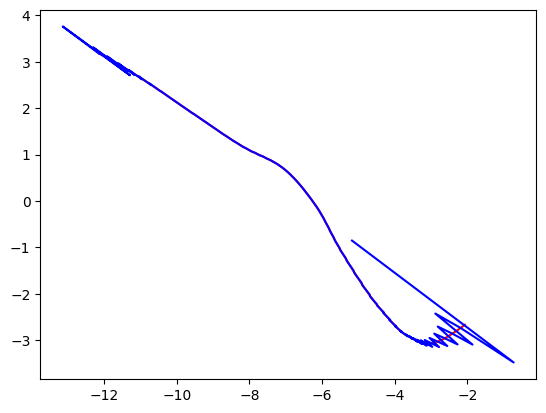

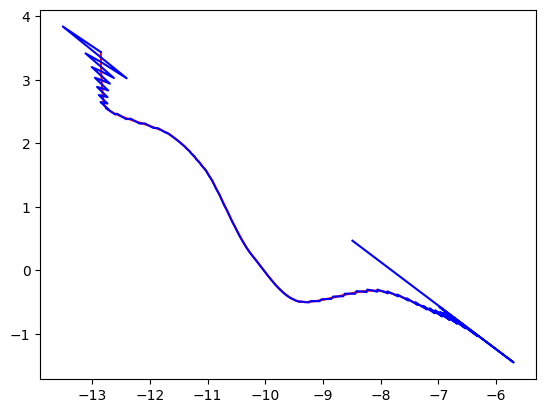

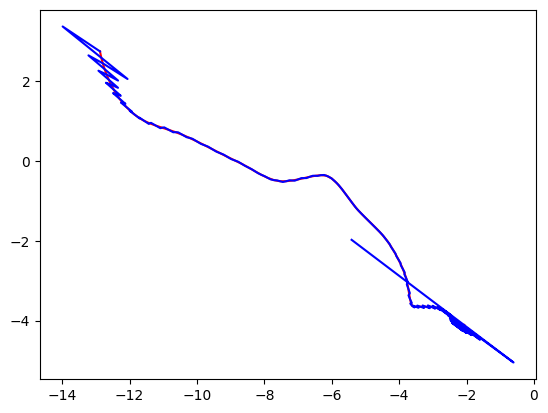

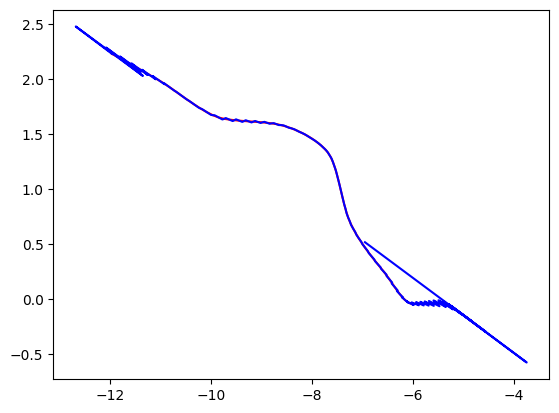

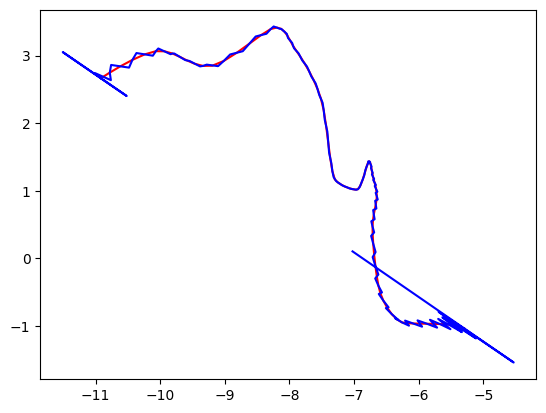

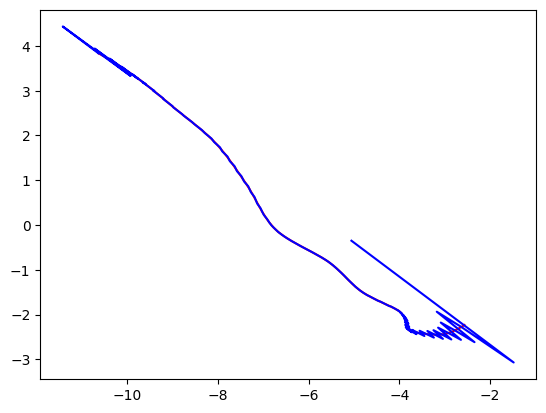

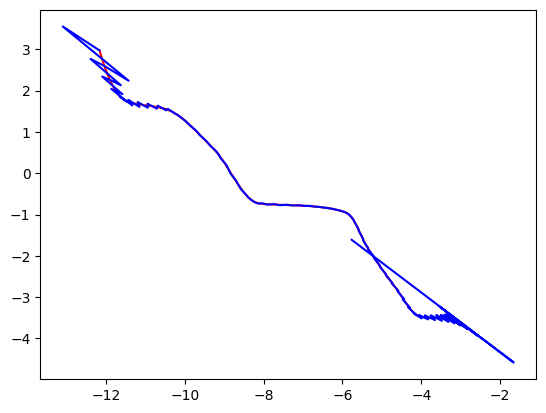

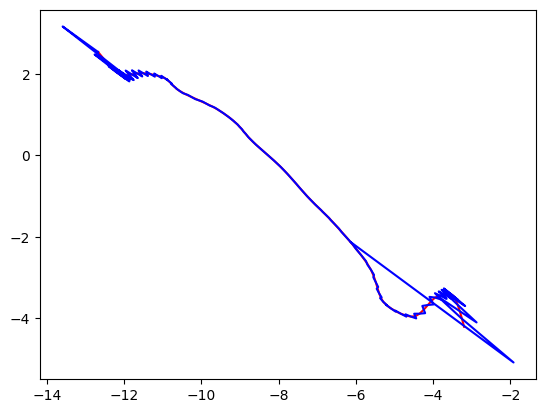

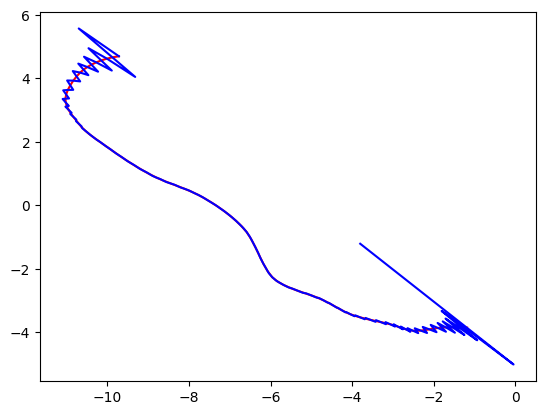

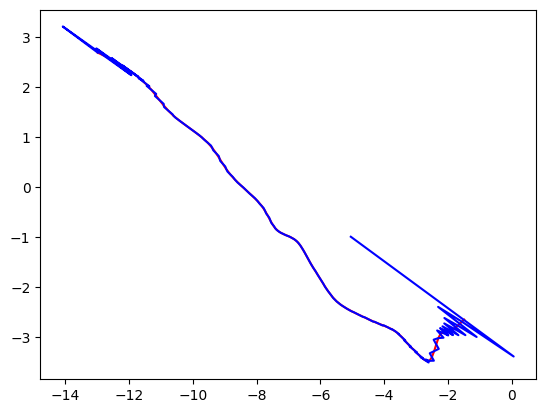

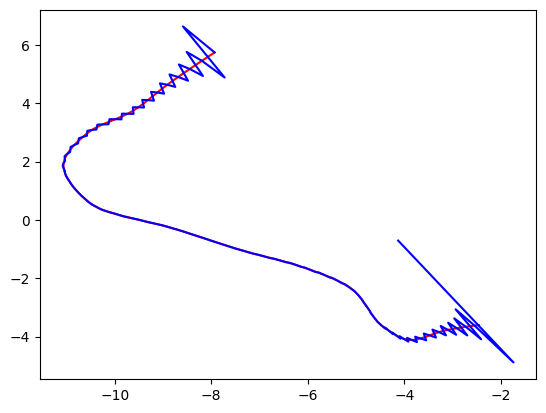

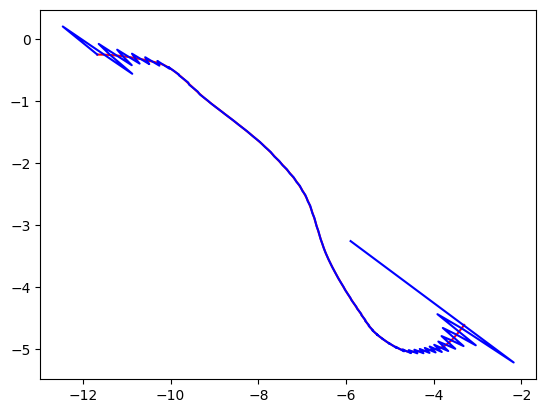

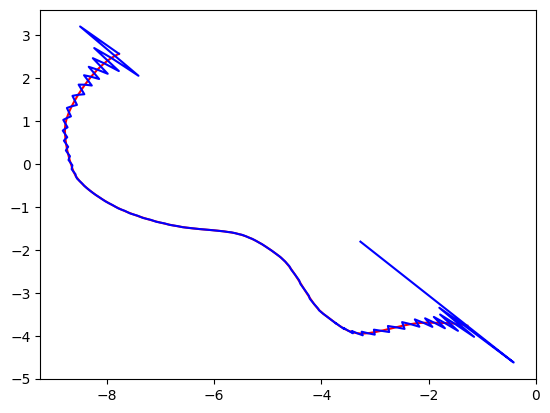

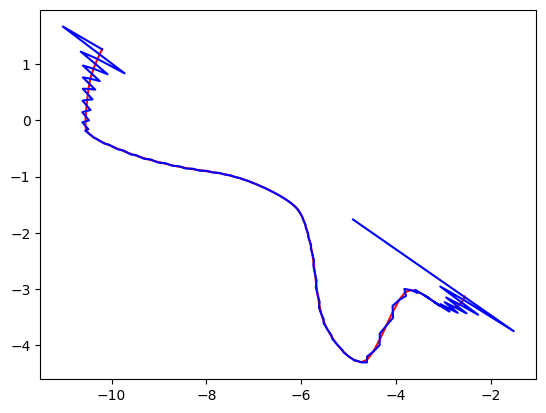

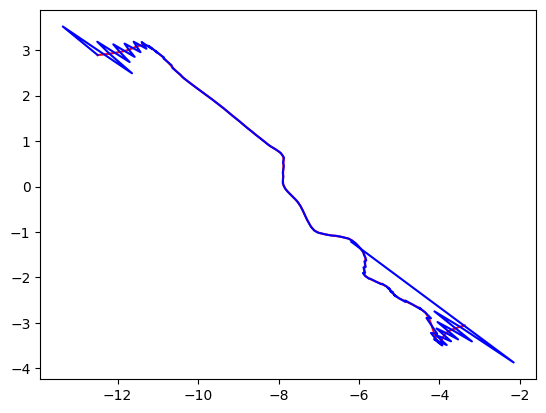

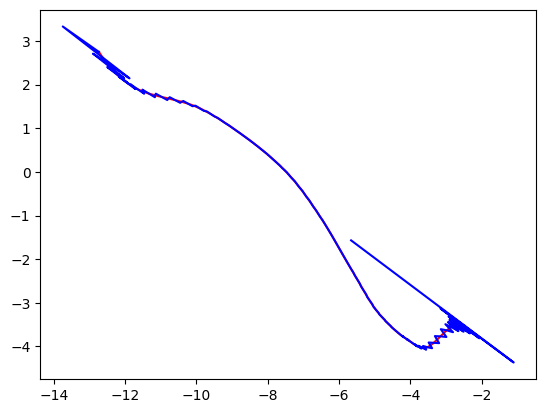

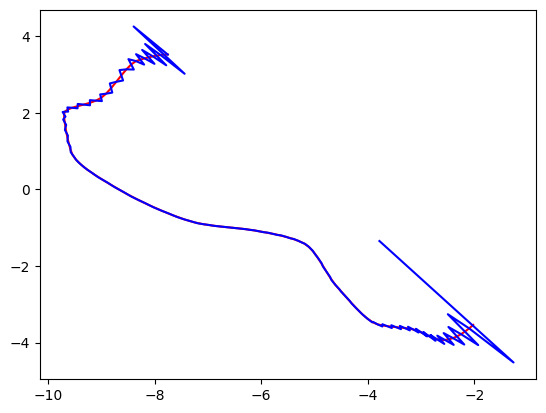

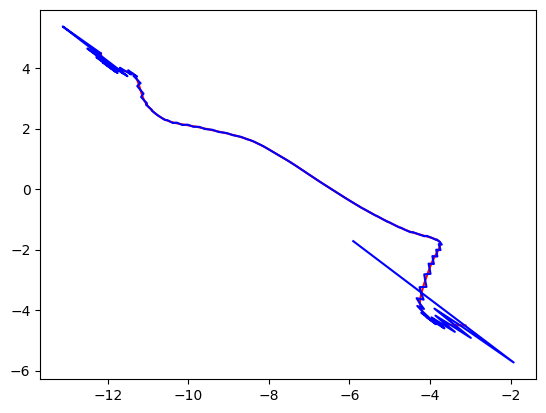

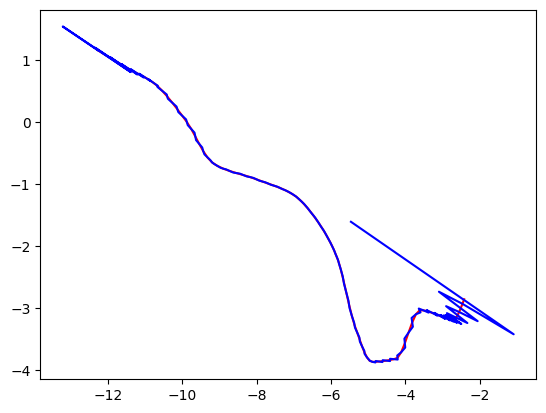

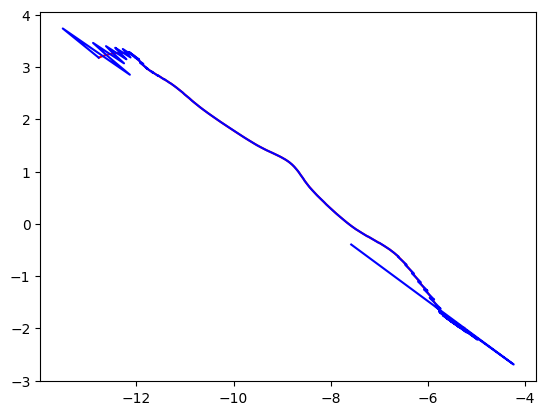

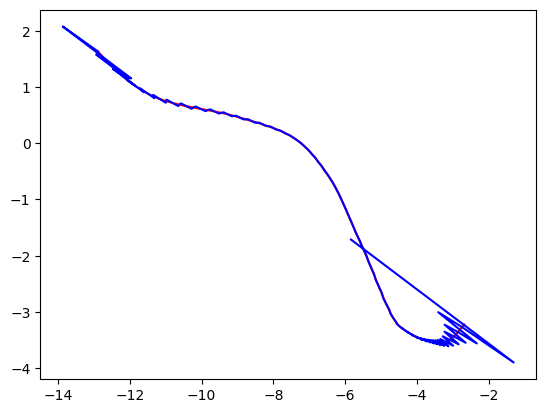

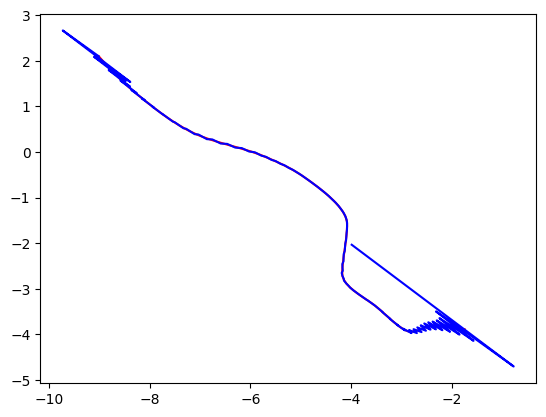

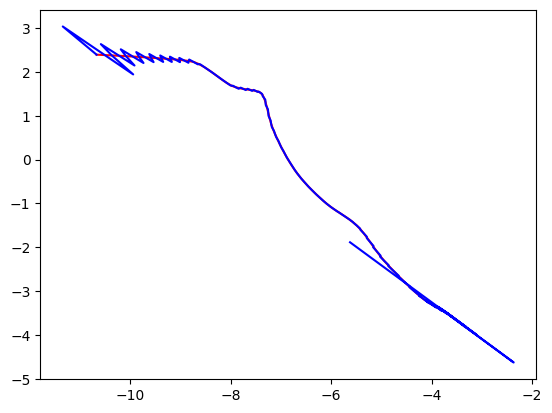

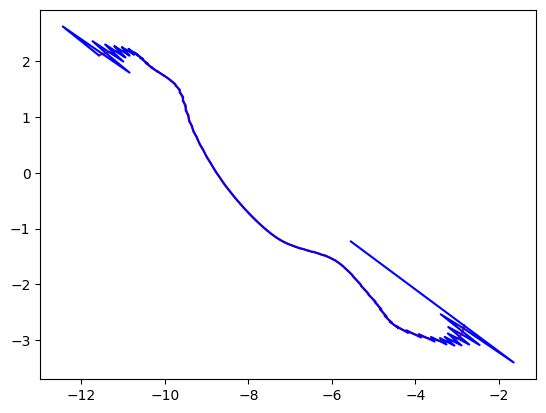

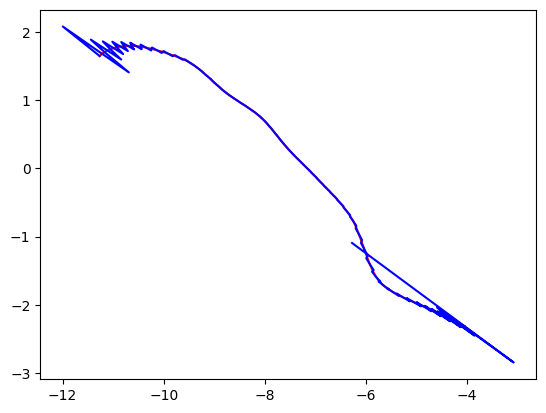

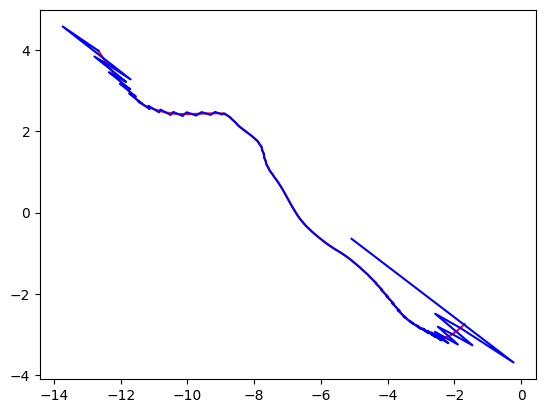

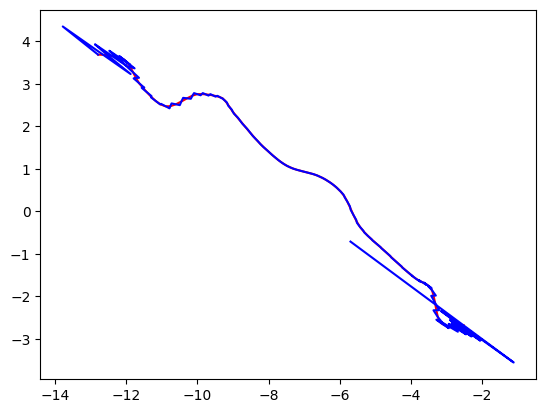

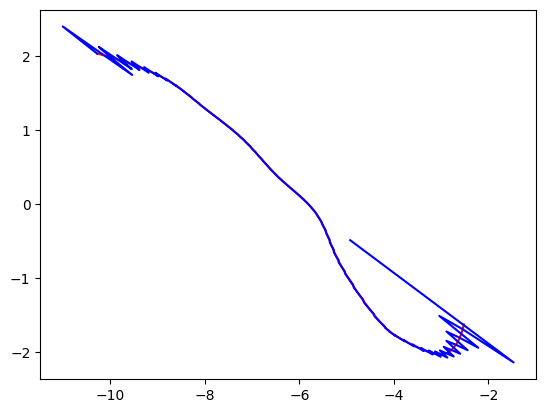

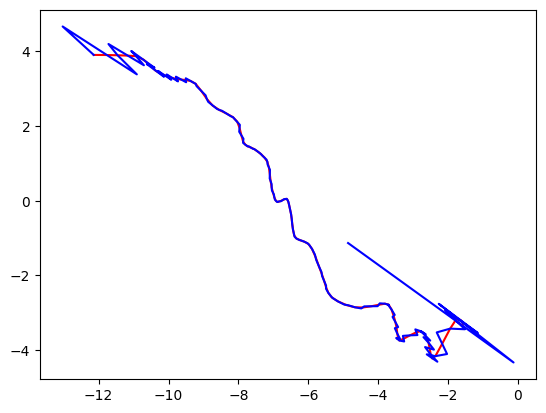

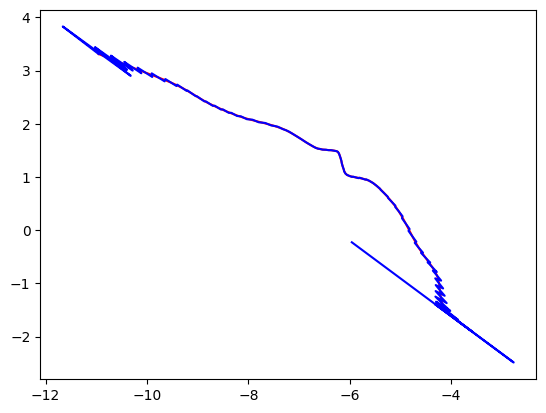

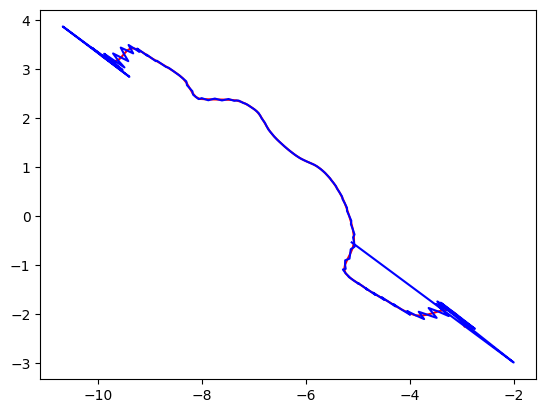

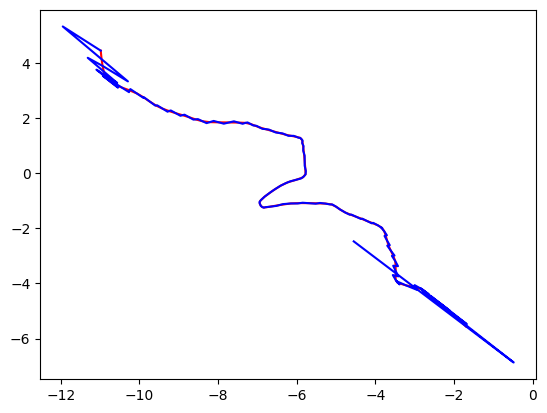

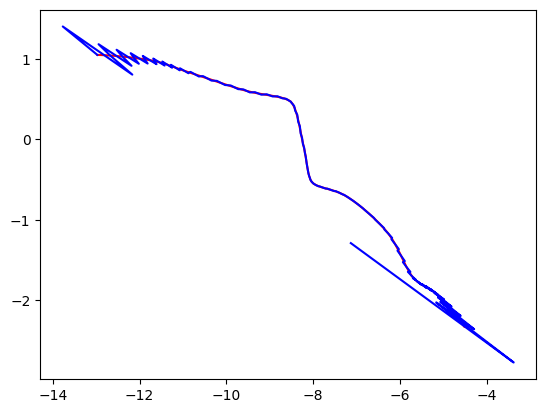

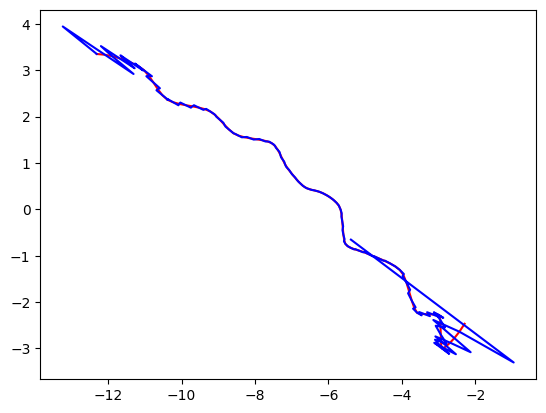

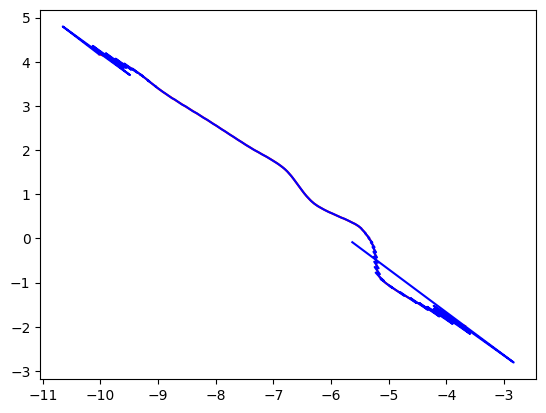

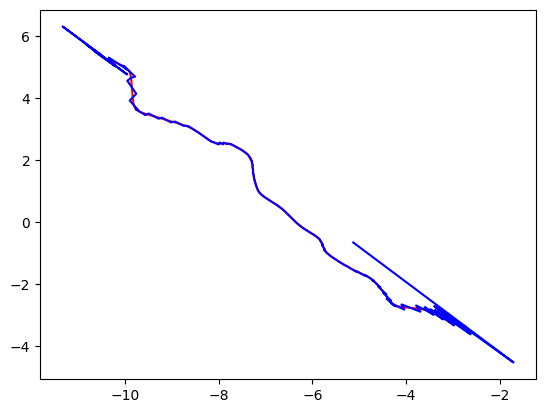

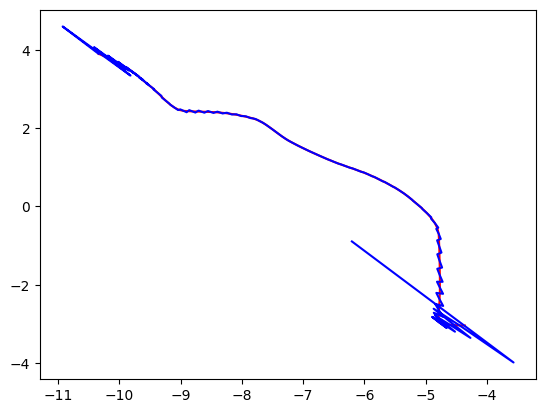

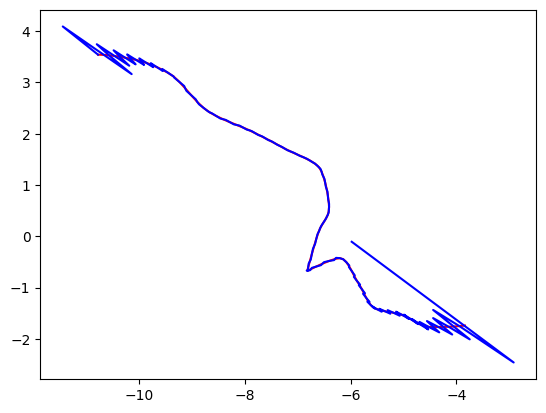

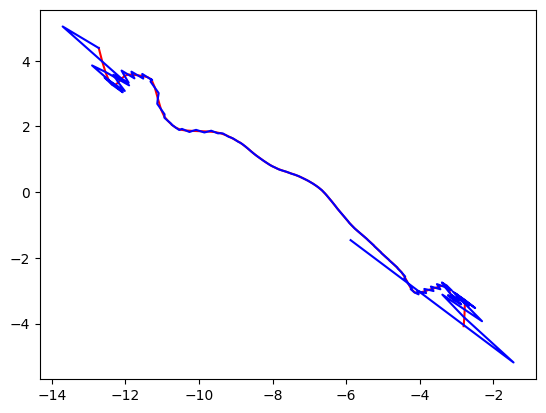

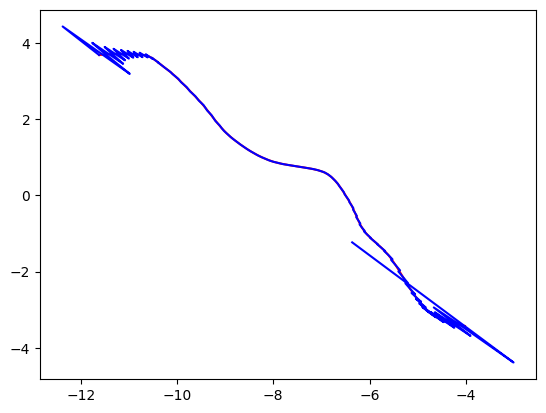

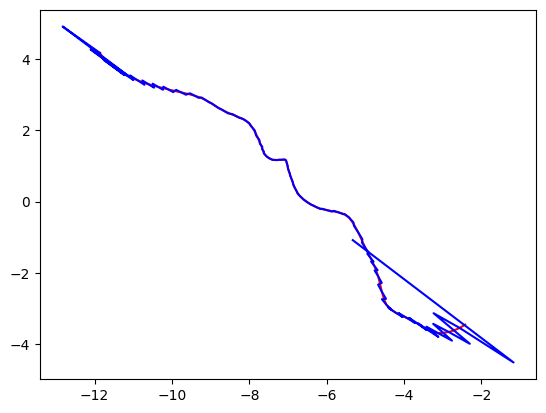

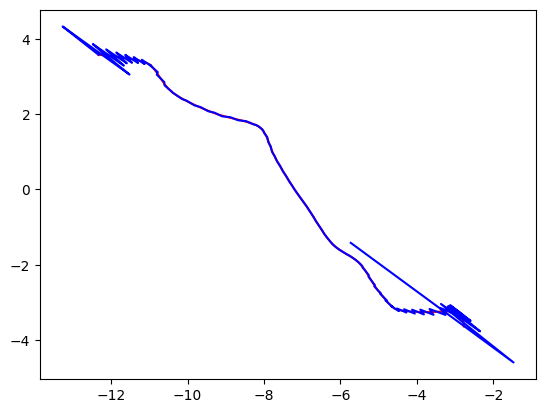

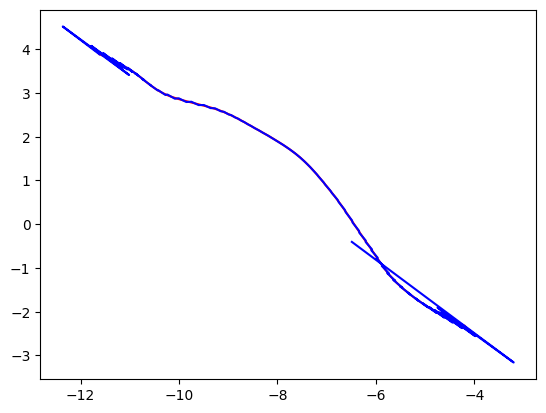

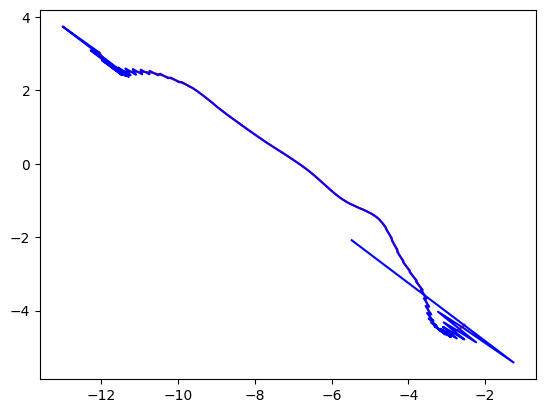

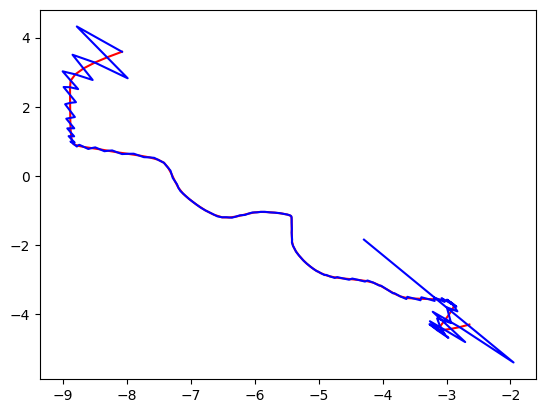

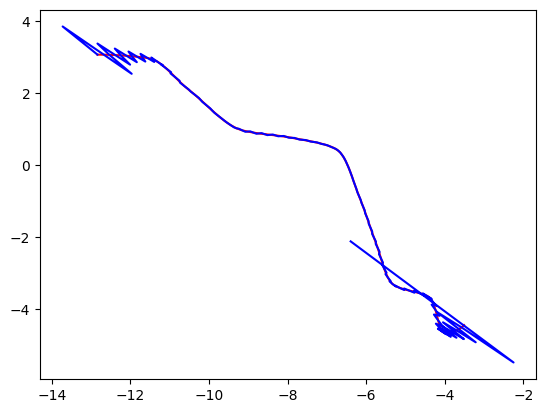

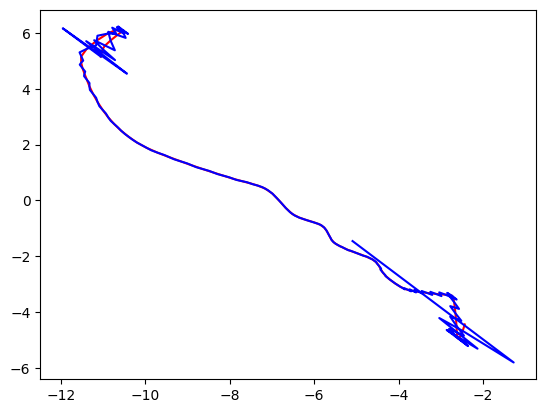

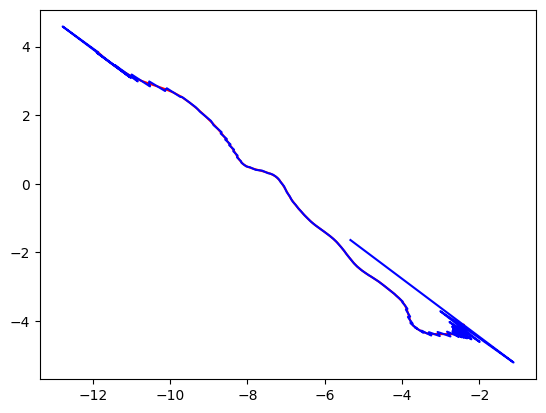

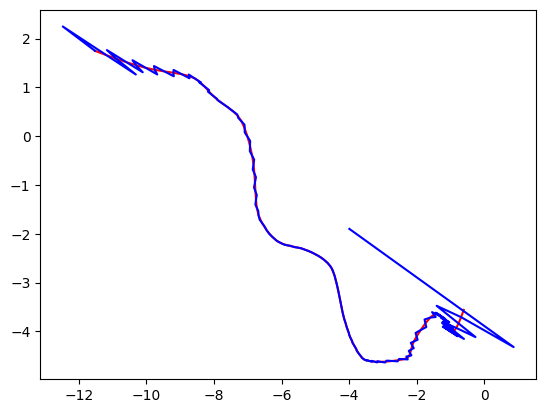

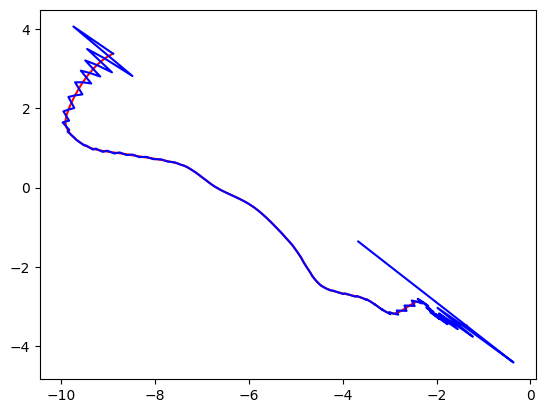

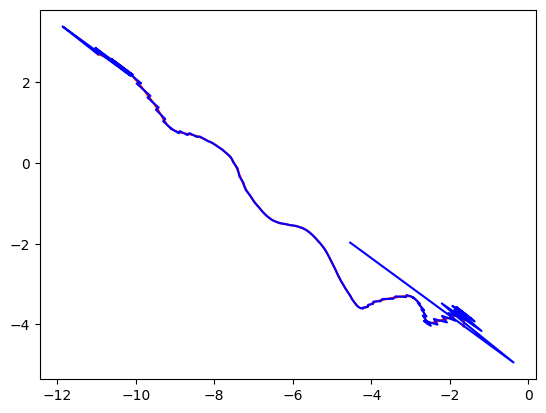

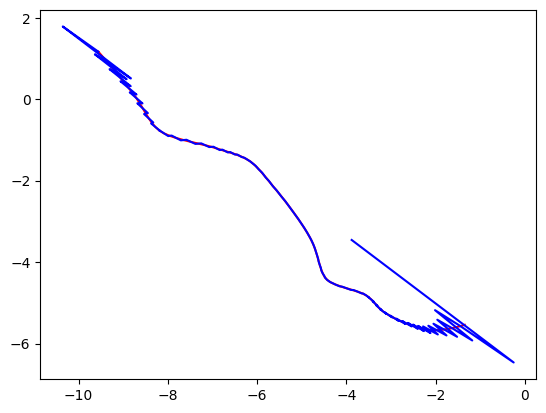

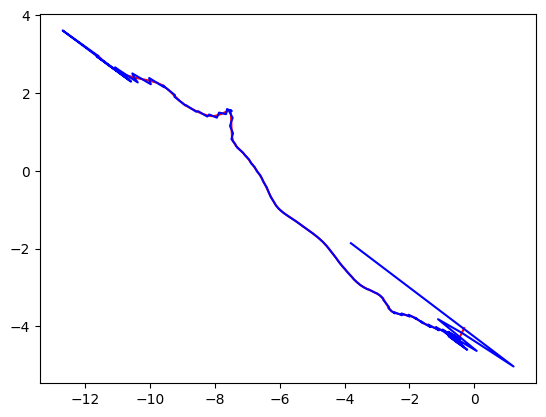

In [107]:
for i,x in enumerate(xs):
    x = xs[i]
    y = ys[i]
    x_resamp = signal.resample(x, 150) # pad with last values
    y_resamp = signal.resample(y, 150)
    plt.plot(x,y,c='red')
    plt.plot(x_resamp,y_resamp,c='blue') 
    plt.show()
    plt.close()